In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# Store object data types
feature_object = df.select_dtypes(include='object')

In [6]:
# To check unique values or values counts.
for col in feature_object.columns:
    print(f"\nColumn: {col}")
    print(feature_object[col].value_counts())


Column: mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64

Column: guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64

Column: basement
basement
no     354
yes    191
Name: count, dtype: int64

Column: hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

Column: airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64

Column: prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64

Column: furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [7]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [8]:
# Set figure size for subplots
plt.figure(figsize=(18, 5 * (len(categorical_cols) + len(numerical_cols)//2)))

plot_index = 1

<Figure size 1800x5000 with 0 Axes>

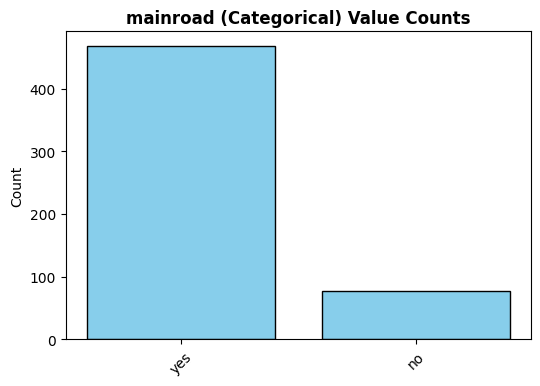

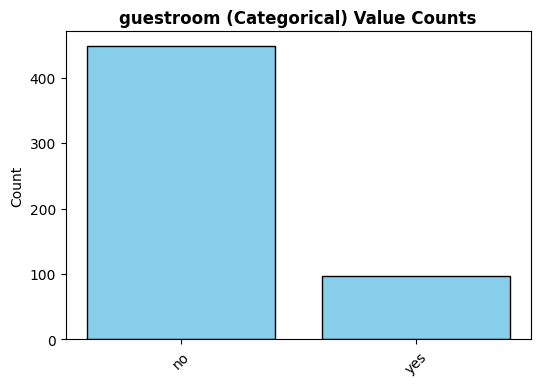

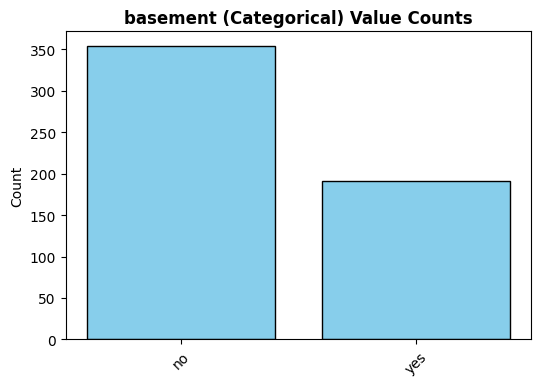

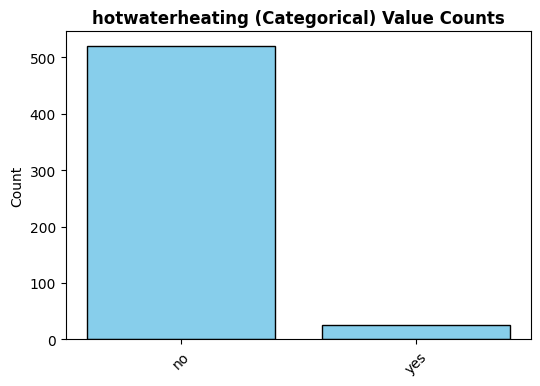

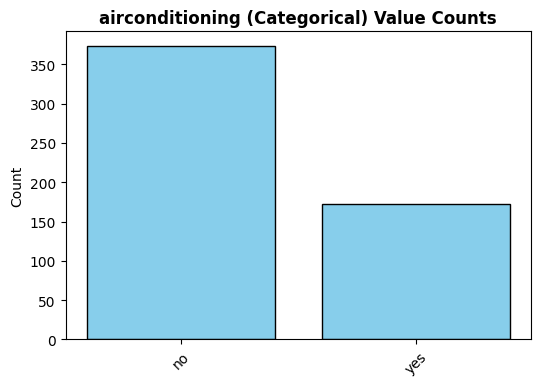

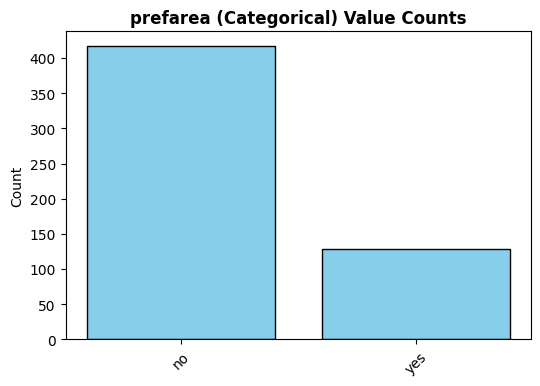

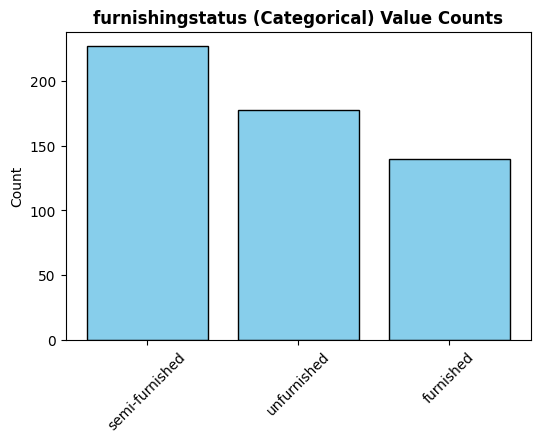

In [9]:
for col in categorical_cols:
    counts = df[col].value_counts()

    plt.figure(figsize=(6, 4))  # separate figure for each column
    plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
    plt.title(f'{col} (Categorical) Value Counts', fontsize=12, fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

> **Note:** Some features are clearly imbalanced (e.g., `hotwaterheating` and `mainroad`).
> However, for this project, our main goal is to build a **robust end-to-end ML pipeline** that works from development to production.
> Handling imbalanced data or feature engineering improvements can be added later in the pipeline.

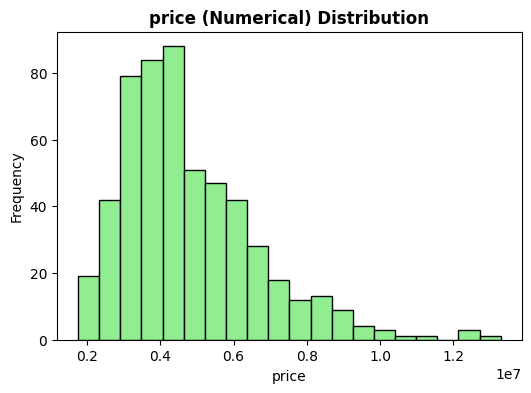

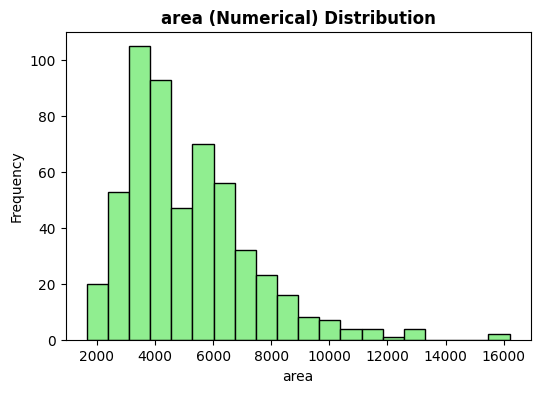

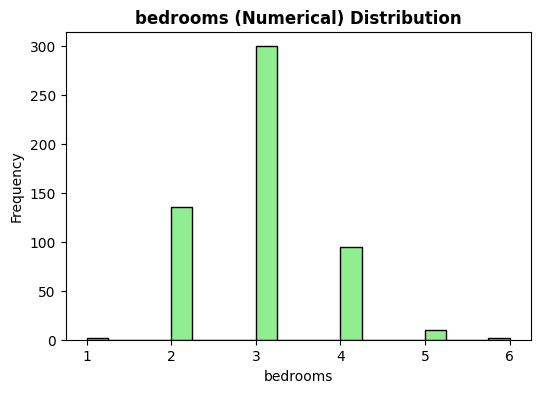

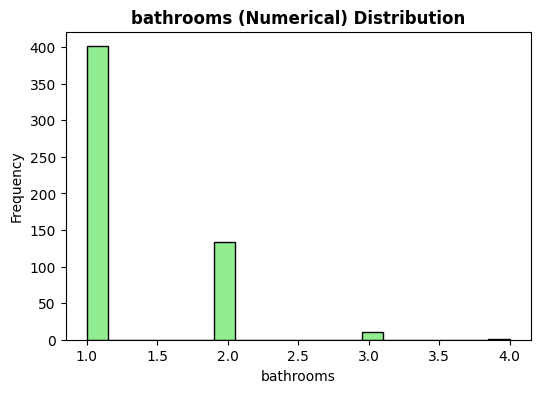

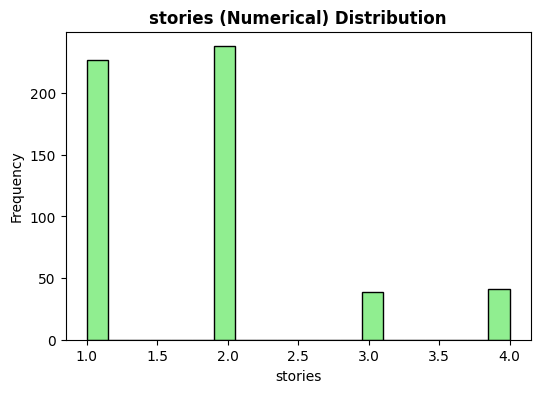

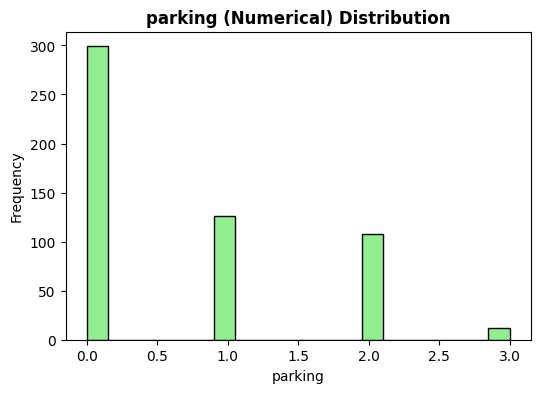

In [10]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))  # separate figure for each column
    plt.hist(df[col], bins=20, color='lightgreen', edgecolor='black')
    plt.title(f'{col} (Numerical) Distribution', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

> **Note:** Some numerical features show outliers or skewed distributions.
> However, for this project, our main goal is to build a **robust end-to-end ML pipeline** that works from development to production.
> Handling outliers or additional feature engineering can be added later in the pipeline.

In [11]:
# Binary encoding
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning',
               'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [12]:
# One-hot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


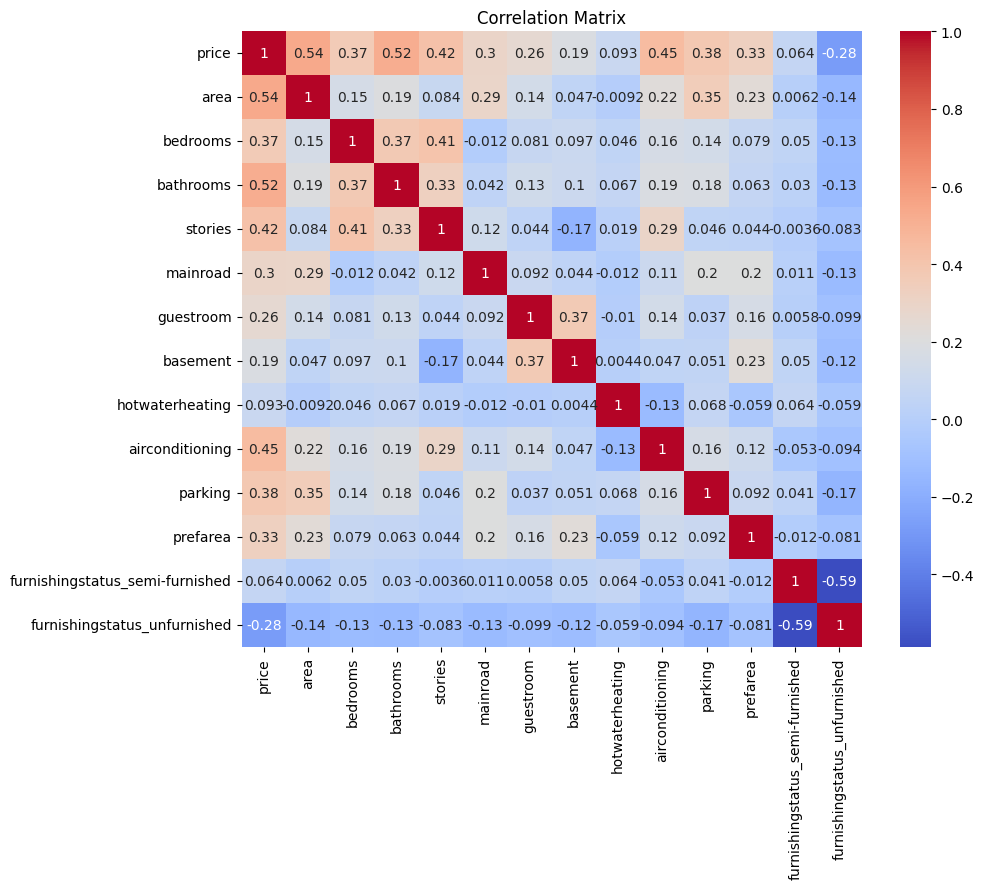

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()